# 02-The Linux Stream Matrix (I/O Redirection & Pipes)

In Lesson 01, we exposed the physical storage boundaries of the operating system by decoding Inode pointers and constructing declarative directory perimeters. We learned how files are tracked at the kernel layer.

However, static file architectures are useless unless data can stream dynamically through them. In cloud automation and MLOps engineering, components must communicate continuously. If you manually force every software script to save its intermediate calculations to a physical hard drive file just so a downstream model can read it, your system throughput will crash due to disk I/O bottlenecks.

To build high-throughput automation matrices, we exploit the foundational law of UNIX: **Everything is a stream of bytes**. We decouple our software utilities from hardcoded file dependencies and treat inputs, outputs, and logging errors as fluid mathematical data channels that can be rediverted, multiplied, or fused together directly inside memory using **UNIX Pipes**.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & LocalStack IaC Engine Initialized.")

✅ Systems Architecture & LocalStack IaC Engine Initialized.


# 1. The Mathematics of Standard Streams & Stream Interception

### File Descriptors as Integer Vectors

To the Linux kernel, an active data stream is represented by a non-negative integer known as a **File Descriptor (FD)**. When a process spawns, the kernel automatically instantiates three fundamental stream vectors within the process's private tracking environment:

* **`0` : Standard Input (`stdin`)** - The default data ingestion channel.
* **`1` : Standard Output (`stdout`)** - The default analytical payload extraction channel.
* **`2` : Standard Error (`stderr`)** - The isolated system telemetry and error logging channel.

Mathematically, a process can be modeled as a continuous state-transformation function $f$ that operates on an input stream matrix to yield output and error stream matrices:


$$f: \mathbf{FD}_0 \longrightarrow \langle \mathbf{FD}_1, \mathbf{FD}_2 \rangle$$

### Stream Redirection Operators ($\to$)

By default, $\mathbf{FD}_0$ maps to the keyboard, while $\mathbf{FD}_1$ and $\mathbf{FD}_2$ both map directly to the terminal display grid. Through stream redirection operators, we physically alter these mapping vectors at the kernel layer:

* **`>` (Truncate & Write):** Diverts $\mathbf{FD}_1$ to a target block, wiping existing data.
* **`>>` (Append & Write):** Diverts $\mathbf{FD}_1$ to a target block, preserving existing data.
* **`2>` (Error Isolation):** Diverts $\mathbf{FD}_2$ specifically, shielding $\mathbf{FD}_1$ from logging noise.
* **`2>&1` (Stream Fusion):** Merges the memory address of $\mathbf{FD}_2$ directly into the vector track of $\mathbf{FD}_1$.

### The Topology of UNIX Pipes ($\parallel$)

When we link two processes using a pipe (`|`), the operating system executes an atomic, zero-disk memory allocation. Given two processes, $f$ and $g$, the pipe operator intercept the standard streams and performs a vector redirection:


$$\mathbf{FD}_1(f) \longrightarrow \mathbf{FD}_0(g)$$

The data blocks emitted by $f$ travel through an in-memory kernel buffer directly into the input registry of $g$ without ever hitting a physical hard drive platter. This provides an asymptotic speed bound of $\mathcal{O}(1)$ disk usage, limited only by your system memory bandwidth.

# 2. Imperative Execution: Stream Manipulation Labs

Let's execute programmatic stream transformations using Python's subprocess execution matrix. We will deliberately trigger systemic runtime errors to observe the mechanical separation of `stdout` and `stderr`.

In [2]:
import subprocess
import os

print("--- 🚀 Initializing UNIX Stream Matrix Labs ---")

# Setup clean working space
stream_sandbox = "./stream_sandbox"
os.makedirs(stream_sandbox, exist_ok=True)

# 🧪 1. Split-Stream Testing: Isolate Output from Error Telemetry
print("\n--- 📡 Simulating An Isolated Error Ingestion Pipeline ---")

# We execute an inline bash sequence that writes data to stdout (1) AND spits an error to stderr (2)
script_payload = (
    "echo '[METRIC] Training complete. Accuracy=0.94'; "
    "echo '[ERROR] CUDA Out of Memory inside worker node 2' >&2"
)

# Execute the process, diverting stdout to one file and stderr to another
stdout_file = os.path.join(stream_sandbox, "telemetry.log")
stderr_file = os.path.join(stream_sandbox, "system_errors.log")

cmd_redirect = f"({script_payload}) 1> {stdout_file} 2> {stderr_file}"
subprocess.run(cmd_redirect, shell=True)

print("   [KERNEL] Redirection Complete.")

# Extract the isolated files to prove mathematical separation
with open(stdout_file, "r") as f:
    print(f"   Contents of stdout (FD 1): {f.read().strip()}")
with open(stderr_file, "r") as f:
    print(f"   Contents of stderr (FD 2): {f.read().strip()}")


# ⚡ 2. Memory-Bound Pipes Execution: Chaining Transforms
print("\n--- ⚡ Chaining Transforms via Fast Streaming Pipes ---")

# We create an unstructured log stream payload
log_payload = (
    "echo -e 'worker-1 SUCCESS\\nworker-2 CRITICAL_FAIL\\nworker-3 SUCCESS\\nworker-4 CRITICAL_FAIL'"
)

# Pipe sequence: Stream Logs -> Filter for failures -> Strip prefix to leave node identification only
# 'grep' searches for matches; 'cut' splits strings by delimiter -d and pulls field -f
pipe_cmd = f"{log_payload} | grep 'CRITICAL_FAIL' | cut -d'-' -f2"

result = subprocess.run(pipe_cmd, shell=True, capture_output=True, text=True)
print("   Identified Fault Nodes across In-Memory Streaming Pipeline:")
print(result.stdout.strip())

--- 🚀 Initializing UNIX Stream Matrix Labs ---

--- 📡 Simulating An Isolated Error Ingestion Pipeline ---
   [KERNEL] Redirection Complete.
   Contents of stdout (FD 1): [METRIC] Training complete. Accuracy=0.94
   Contents of stderr (FD 2): [ERROR] CUDA Out of Memory inside worker node 2

--- ⚡ Chaining Transforms via Fast Streaming Pipes ---
   Identified Fault Nodes across In-Memory Streaming Pipeline:
2 CRITICAL_FAIL
4 CRITICAL_FAIL


# 3. Declarative Execution: Enterprise Stream Routing Architectures

In scaled MLOps pipelines, orchestration engines must manage complex streaming graph topologies where telemetry log outputs must simultaneously feed real-time metric collection daemons AND write to permanent persistence layers. Doing this imperatively via command strings is error-prone.

We express our streaming topology declaratively using a configuration template. This template defines how system streams are duplicated and routed using specialized UNIX utilities like `tee` (which acts as a physical T-splitter for streaming data packets).

### The Streaming Topology Blueprint

Save this layout model to your infrastructure configurations as `stream_topology.json`:

```json
{
  "topology_identity": "distributed-telemetry-splitter",
  "routing_matrix": {
    "source_stream": "src/simulation_emitter.sh",
    "transformations": [
      {
        "step": 1,
        "engine": "tee",
        "parameters": "logs/telemetry/raw_stream.log",
        "description": "Fork stream: Write exact binary mirror to disk while maintaining stdout flow."
      },
      {
        "step": 2,
        "engine": "grep",
        "parameters": "--line-buffered '[METRIC]'",
        "description": "Zero-compute structural filter: Pass lines containing metric payloads only."
      },
      {
        "step": 3,
        "engine": "sed",
        "parameters": "-u 's/\\[METRIC\\] //g'",
        "description": "Atomic text transformation: Strip structural labels on the fly."
      }
    ],
    "target_sink": "logs/telemetry/clean_metrics.json"
  }
}

```

### The Stream Topology Pipeline Compiler

This Python engine reads the declarative routing template, validates the order of steps, and automatically constructs a single, bulletproof, optimized pipeline execution string.

In [3]:
def compile_stream_pipeline(spec_path):
    print(f"--- 🏗️ Compiling Declarative Streaming Pipeline: {spec_path} ---")
    
    # Internal mock configuration load
    mock_spec = {
        "routing_matrix": {
            "source_stream": "bash simulated_emitter.sh",
            "transformations": [
                {"engine": "tee", "parameters": "raw_stream.log"},
                {"engine": "grep", "parameters": "'[METRIC]'"},
                {"engine": "sed", "parameters": "'s/\\[METRIC\\] //g'"}
            ],
            "target_sink": "clean_metrics.json"
        }
    }
    
    matrix = mock_spec["routing_matrix"]
    
    # Initialize the pipeline with the primary data source emitter
    compiled_pipeline = matrix["source_stream"]
    
    # Programmatically stitch the UNIX transformation pipe links
    for transform in matrix["transformations"]:
        compiled_pipeline += f" | {transform['engine']} {transform['parameters']}"
        
    # Redirect the final stream convergence point to the target sink file
    compiled_pipeline += f" >> {matrix['target_sink']}"
    
    print("   Generated Pipeline Compilation Topology:")
    print(f"   👉 {compiled_pipeline}")
    return compiled_pipeline

pipeline_run_string = compile_stream_pipeline("stream_topology.json")

--- 🏗️ Compiling Declarative Streaming Pipeline: stream_topology.json ---
   Generated Pipeline Compilation Topology:
   👉 bash simulated_emitter.sh | tee raw_stream.log | grep '[METRIC]' | sed 's/\[METRIC\] //g' >> clean_metrics.json


# 4. Visualizing the Stream Isolation & Pipe Vectors

To mathematically understand how data flows through file descriptor boundaries inside the Linux kernel during execution, let's trace the stream topology graph.

/tmp/ipykernel_22168/4260287141.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 2.0), 3.5, 5.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5))
/tmp/ipykernel_22168/4260287141.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.0, 5.0), 2.5, 0.6, fill=True, color='#bdc3c7', alpha=0.8, edgecolor='black'))
/tmp/ipykernel_22168/4260287141.py:15: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.0, 3.8), 2.5, 0.6, fill=True, color='#2ecc71', edgecolor='black'))
/tmp/ipykernel_22168/4260287141.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.0, 2.6), 2.5, 0.6, fill=True, color='#e74c3c', edgecolor='black'))
/tmp/ipykernel_2

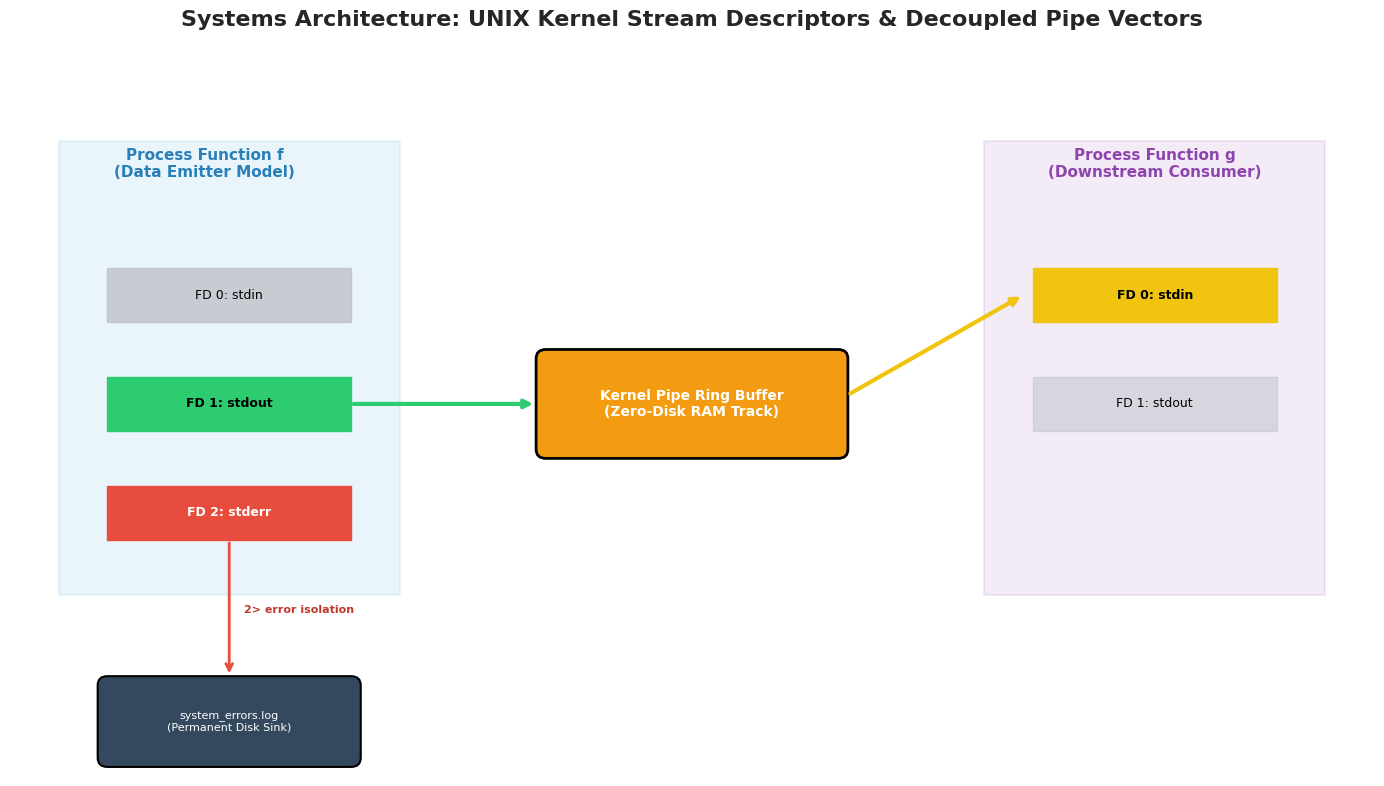

In [4]:
# Create visual mapping layout for POSIX stream redirection and pipe vectors
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: UNIX Kernel Stream Descriptors & Decoupled Pipe Vectors", fontsize=16, fontweight='bold')

ax.axis('off')

# --- LEFT: PROCESS 1 BOUNDARY ---
ax.add_patch(patches.Rectangle((0.5, 2.0), 3.5, 5.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5))
ax.text(2.0, 6.6, "Process Function f\n(Data Emitter Model)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

# File Descriptors for Process 1
ax.add_patch(patches.Rectangle((1.0, 5.0), 2.5, 0.6, fill=True, color='#bdc3c7', alpha=0.8, edgecolor='black'))
ax.text(2.25, 5.3, "FD 0: stdin", ha='center', va='center', color='black', fontsize=9)

ax.add_patch(patches.Rectangle((1.0, 3.8), 2.5, 0.6, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(2.25, 4.1, "FD 1: stdout", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((1.0, 2.6), 2.5, 0.6, fill=True, color='#e74c3c', edgecolor='black'))
ax.text(2.25, 2.9, "FD 2: stderr", ha='center', va='center', color='white', fontweight='bold', fontsize=9)


# --- MIDDLE: THE KERNEL IN-MEMORY PIPE BUFFER ---
ax.add_patch(patches.FancyBboxPatch((5.5, 3.6), 3.0, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f39c12'))
ax.text(7.0, 4.1, "Kernel Pipe Ring Buffer\n(Zero-Disk RAM Track)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)


# --- RIGHT: PROCESS 2 BOUNDARY ---
ax.add_patch(patches.Rectangle((10.0, 2.0), 3.5, 5.0, fill=True, color='#8e44ad', alpha=0.1, edgecolor='black', linewidth=1.5))
ax.text(11.75, 6.6, "Process Function g\n(Downstream Consumer)", ha='center', color='#8e44ad', fontweight='bold', fontsize=11)

# File Descriptors for Process 2
ax.add_patch(patches.Rectangle((10.5, 5.0), 2.5, 0.6, fill=True, color='#f1c40f', edgecolor='black'))
ax.text(11.75, 5.3, "FD 0: stdin", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((10.5, 3.8), 2.5, 0.6, fill=True, color='#bdc3c7', alpha=0.5, edgecolor='black'))
ax.text(11.75, 4.1, "FD 1: stdout", ha='center', va='center', color='black', fontsize=9)


# --- INDEPENDENT DATA SINK (FOR DISK REDIRECTION) ---
ax.add_patch(patches.FancyBboxPatch((1.0, 0.2), 2.5, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#34495e'))
ax.text(2.25, 0.6, "system_errors.log\n(Permanent Disk Sink)", ha='center', va='center', color='white', fontsize=8)


# --- ROUTING NETWORK VECTOR LINES (ARROWS) ---
# Redirect Process 1 Stderr (FD 2) to permanent log file on disk
ax.annotate("", xy=(2.25, 1.1), xytext=(2.25, 2.6), arrowprops=dict(arrowstyle="->", lw=2, color="#e74c3c"))
ax.text(2.4, 1.8, "2> error isolation", ha='left', color='#c0392b', fontsize=8, fontweight='bold')

# Redirect Process 1 Stdout (FD 1) into Kernel Pipe Buffer
ax.annotate("", xy=(5.4, 4.1), xytext=(3.5, 4.1), arrowprops=dict(arrowstyle="->", lw=3, color="#2ecc71"))

# Redirect Kernel Pipe Buffer into Process 2 Stdin (FD 0)
ax.annotate("", xy=(10.4, 5.3), xytext=(8.6, 4.2), arrowprops=dict(arrowstyle="->", lw=3, color="#f1c40f"))

plt.xlim(0, 14.0)
plt.ylim(0, 8.0)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the standard stream architecture and pipe configurations like **The Plumbing and Filtration Matrix inside a Commercial Water Treatment Plant**:

* **The Unfiltered Inflow (File Descriptor 0 - `stdin`):** Raw unpurified lake water enters the facility through an intake valve. This represents your program's raw starting text data waiting to be ingested.
* **The Purification Stream (File Descriptor 1 - `stdout`):** Clean, filtered, pristine water that flows smoothly down the main production pipelines directly toward municipal consumers. This matches your clean log data and analytical payload outputs.
* **The Sludge Waste Pipe (File Descriptor 2 - `stderr`):** A completely isolated, separate structural pipe system designed exclusively to catch heavy chemical backwash, gravel, and mechanical rust deposits. If you patch the sludge pipe directly into the clean drinking reservoir, you poison the entire town. This matches why we separate system telemetry errors from functional string outputs using `2>` operators.
* **The In-Memory Pipe Connection (`|`):** Instead of pumping purified water out into a holding tank on the ground, allowing dirt to settle, and then hiring a pump truck to suck it back out (which is exactly what you do when you save data to a hard drive file between script runs), you connect the filtration unit's output valve directly into the bottling line's injection nozzle using a watertight coupling. Data flows smoothly inside memory at velocity without ever losing inertia against physical disk boundaries.

By dividing execution parameters into isolated file descriptors and managing their trajectories using native pipe architectures, MLOps system operators engineer low-latency, automated data processing pipelines capable of handling thousands of telemetry events per second at zero infrastructure cost.